In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing() 
df = pd.DataFrame( 
    housing.data, 
    columns=housing.feature_names 
) 
df["Price"] = housing.target 
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape

(20640, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [8]:
df.duplicated().value_counts()

False    20640
Name: count, dtype: int64

<Axes: xlabel='Price', ylabel='Count'>

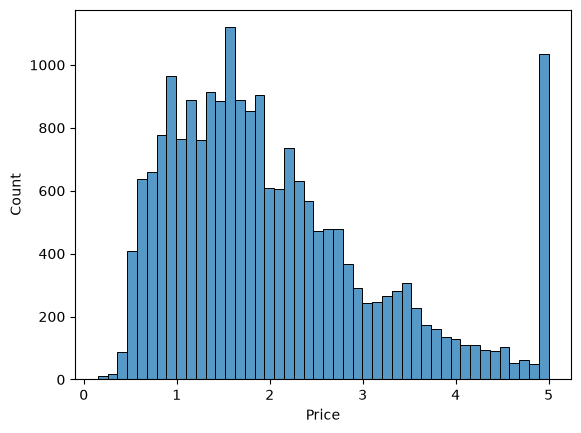

In [9]:
sns.histplot(df["Price"])

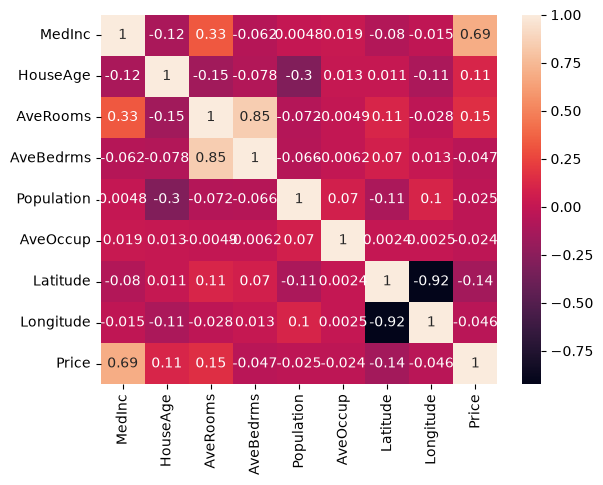

In [10]:
sns.heatmap(df.corr(), annot=True) 
plt.show()

<Axes: xlabel='MedInc', ylabel='Price'>

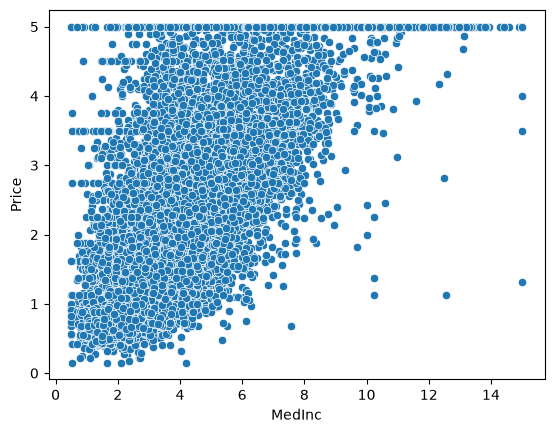

In [11]:
sns.scatterplot( 
    x=df["MedInc"], 
    y=df["Price"] 
)

In [12]:
X = df.drop("Price", axis=1) 
y = df["Price"]
Target:Price 

In [13]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2,random_state=42) 

In [14]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [15]:
from sklearn.linear_model import LinearRegression 
lr = LinearRegression() 
lr.fit(X_train, y_train) 
pred_lr = lr.predict(X_test) 

In [16]:
from sklearn.tree import DecisionTreeRegressor 
dt = DecisionTreeRegressor() 
dt.fit(X_train, y_train) 
pred_dt = dt.predict(X_test) 

In [17]:
from sklearn.ensemble import RandomForestRegressor 
rf = RandomForestRegressor() 
rf.fit(X_train, y_train) 
pred_rf = rf.predict(X_test)

In [18]:
from sklearn.neighbors import KNeighborsRegressor 
knn = KNeighborsRegressor() 
knn.fit(X_train_scaled, y_train) 
pred_knn = knn.predict(X_test_scaled) 

In [19]:
from sklearn.tree import DecisionTreeRegressor 
dt = DecisionTreeRegressor() 
dt.fit(X_train, y_train) 
pred_dt = dt.predict(X_test)

In [20]:
from sklearn.metrics import r2_score 
print(r2_score(y_test, pred_lr))

0.575787706032451


In [21]:
from sklearn.metrics import mean_absolute_error 
mean_absolute_error(y_test, pred_lr)

0.5332001304956555

In [22]:
from sklearn.metrics import root_mean_squared_error 
 
root_mean_squared_error(y_test,  pred_lr)

0.7455813830127763

In [23]:
import pandas as pd 
importance = pd.DataFrame({ 
    "Feature": X.columns, 
    "Importance": rf.feature_importances_ 
}) 
importance.sort_values( 
    by="Importance", 
    ascending=False 
)

,Feature,Importance
0,MedInc,0.526666
5,AveOccup,0.137495
6,Latitude,0.088746
7,Longitude,0.088448
1,HouseAge,0.054638
2,AveRooms,0.044158
4,Population,0.030614
3,AveBedrms,0.029235


In [25]:
import pickle
from sklearn.linear_model import LinearRegression

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Save new model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [26]:
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!
